In [33]:
from pathlib import Path
IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def show_tree(folder, depth=0, max_depth=4):
    folder = Path(folder)
    n = sum(1 for f in folder.rglob("*") if f.suffix.lower() in IMG_EXT)
    print("    " * depth + f"{folder.name}/  ({n} images)")
    if depth < max_depth:
        for sub in sorted(p for p in folder.iterdir() if p.is_dir()):
            show_tree(sub, depth + 1, max_depth)

show_tree("/kaggle/input")

input/  (6107 images)
    datasets/  (6107 images)
        bhanukachamindu/  (6107 images)
            aloe-colour/  (6107 images)
                Aloe_Vera_Dataset_Colour/  (6107 images)


In [2]:
import os, sys, random, hashlib, math, time, copy, subprocess
from pathlib import Path
import numpy as np
try:
    import timm
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "timm"], check=True)
    import timm
import torch, torch.nn as nn, torch.nn.functional as F
import torchvision.transforms as T
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import matplotlib.pyplot as plt
from PIL import Image, ImageOps
from concurrent.futures import ThreadPoolExecutor

# ---------------- SETTINGS ----------------
TRAIN_DIR = "/kaggle/input/datasets/bhanukachamindu/aloe-colour"     # folder that contains (or holds, at any depth) the brown / green / yellow folders
UNSEEN_DIR = None       # None = find the unseen photos automatically; False = ignore them; or type a path
UNSEEN_RENAME = {}      # only if the unseen folder names differ from the training ones, e.g. {"rust": "aloe_rust"} (lowercase)
ADD_UNSEEN_FRACTION = 0.0   # 0 = the unseen photos are NEVER used for training (recommended: an honest final test)
                            # 0.5 = train on about half of the unseen photos (whole groups), and test on the other half.
                            # The second notebook automatically leaves the used photos out.

MODEL_NAME = "tresnet_m.miil_in21k_ft_in1k"   # also: tresnet_m.miil_in1k | tresnet_l.miil_in1k | tresnet_v2_l.miil_in21k_ft_in1k
IMG_SIZE = 224
BATCH = 32
EPOCHS = 30
PATIENCE = 8              # stop when the validation macro-F1 has not improved for this many epochs
SAMPLES_PER_EPOCH = 3200  # photos drawn per epoch (one draw per original photo, class balanced)
LR = 2e-4                 # learning rate of the pretrained body
HEAD_LR_MULT = 5          # the new classifier layer learns this many times faster
WEIGHT_DECAY = 0.05
LABEL_SMOOTH = 0.1
USE_MIXUP = False           # CutMix / MixUp between photos of different classes
EMA_DECAY = 0.998
GROUP_SIM = 0.75          # (safety net) photos of the same class with a network-similarity above this count as copies of one original
EMBED_MERGE_ALL = False   # False: the network check only looks at photos whose file name has no augmentation tag. True: it also merges named families.
EXTRA_AUG_TAGS = ""       # extra augmentation words found in your file names, separated by | (e.g. "gamma|cutout")
SEED = 42
PREFIX = "colour"                        # start of the saved file names
POS_CLASS = "green"                  # used for the extra two-group check (lowercase class name)
POS_NAMES = ("good", "not good")
OUT_DIR = "/kaggle/working"
PRETRAINED = True
# ------------------------------------------

IMG_EXT = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}
BASE = MODEL_NAME.split(".")[0]
RES = int(round(IMG_SIZE * 1.15))            # photos are kept at this size, then cropped / resized to IMG_SIZE
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = DEVICE.type == "cuda"
NUM_WORKERS = min(4, os.cpu_count() or 1)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
print("torch", torch.__version__, "| timm", timm.__version__, "| device:", DEVICE)
if int(timm.__version__.split(".")[0]) == 0 and int(timm.__version__.split(".")[1]) < 9:
    print("WARNING: old timm version. If you get 'Unknown pretrained model', run  !pip install -U timm  and restart the notebook.")
if DEVICE.type == "cpu":
    print("WARNING: no GPU found. Turn on the GPU accelerator, training on a CPU is very slow.")

torch 2.10.0+cu128 | timm 1.0.26 | device: cuda


In [34]:
SPLIT_NAMES = {"train", "training", "val", "valid", "validation", "test", "testing"}

def norm(name):
    return name.strip().lower().replace("-", "_").replace(" ", "_")

def list_images(root):
    """All images under root. The class of a photo = name of the folder it sits in (lowercased)."""
    root = Path(root)
    assert root.exists(), f"Folder not found: {root}  (is the dataset added under Input? run the tree cell above)"
    paths, labels = [], []
    for f in sorted(root.rglob("*")):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            cls = norm(f.parent.name)
            if cls in SPLIT_NAMES:
                continue
            paths.append(str(f)); labels.append(cls)
    return paths, labels

def n_images(d):
    return sum(1 for f in Path(d).rglob("*") if f.suffix.lower() in IMG_EXT)

def find_candidates(class_names, min_match=2):
    """Folders under /kaggle/input whose sub-folders match at least min_match of the class names."""
    found = []
    for dirpath, dirnames, _ in os.walk("/kaggle/input"):
        if len({norm(d) for d in dirnames} & set(class_names)) >= min_match:
            found.append(dirpath)
            dirnames[:] = []            # do not look inside
    return found


print("Training folder:", TRAIN_DIR)
tr_paths, tr_labels = list_images(TRAIN_DIR)
CLASSES = sorted(set(tr_labels))
class_to_idx = {c: i for i, c in enumerate(CLASSES)}
K = len(CLASSES); IDX = list(range(K))
counts = {c: tr_labels.count(c) for c in CLASSES}
print("Classes found:", K)
for c in CLASSES:
    print(f"  {c:25s} {counts[c]:5d}  ({counts[c] / len(tr_labels) * 100:4.1f}%)")
print("total:", len(tr_paths))
assert 2 <= K <= 40, "Unexpected number of classes: check that TRAIN_DIR points at the folder holding the class folders."
assert min(counts.values()) >= 12, "A class has fewer than 12 photos, which is too few to split. Remove or merge it."

# the unseen photos (optional here)
if UNSEEN_DIR is None:
    cands = [d for d in find_candidates(CLASSES, min(2, K)) if "unseen" in d.lower()]
    if len(cands) > 1:
        print("Several unseen-looking folders found, none used. Set UNSEEN_DIR:", cands)
    UNSEEN_DIR = cands[0] if len(cands) == 1 else False
if UNSEEN_DIR:
    un_paths, un_labels = list_images(UNSEEN_DIR)
    un_labels = [UNSEEN_RENAME.get(l, l) for l in un_labels]
    assert set(un_labels) <= set(CLASSES), (f"Unseen class names {sorted(set(un_labels) - set(CLASSES))} are not among the training classes {CLASSES}. "
                                            "Fix the folder names or fill in UNSEEN_RENAME.")
    print("\nUnseen folder:", UNSEEN_DIR, "|", len(un_paths), "photos")
else:
    un_paths, un_labels = [], []
    print("\nNo unseen photos attached (that is fine for training).")

paths_all  = tr_paths + un_paths
labels_all = tr_labels + un_labels
y_all = np.array([class_to_idx[l] for l in labels_all])
is_unseen = np.array([False] * len(tr_paths) + [True] * len(un_paths))
train_mask, unseen_mask = ~is_unseen, is_unseen
N = len(paths_all)

Training folder: /kaggle/input/datasets/bhanukachamindu/aloe-colour
Classes found: 3
  brown                       335  ( 5.5%)
  green                      1923  (31.5%)
  yellow                     3849  (63.0%)
total: 6107

No unseen photos attached (that is fine for training).


In [35]:
def load_rgb(p):
    """Open a photo, respect the phone's rotation flag, and resize to RES x RES (kept in memory as uint8)."""
    im = ImageOps.exif_transpose(Image.open(p)).convert("RGB")
    return np.asarray(im.resize((RES, RES), Image.BICUBIC))

def load_all(paths):
    with ThreadPoolExecutor(8) as ex:
        return np.stack(list(ex.map(load_rgb, paths)))

t0 = time.time()
arr = load_all(paths_all)
print(f"loaded {arr.shape} uint8 in {time.time() - t0:.0f}s  ({arr.nbytes / 1e9:.2f} GB)")

loaded (6107, 258, 258, 3) uint8 in 140s  (1.22 GB)


In [36]:
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components

emb_model = timm.create_model(MODEL_NAME, pretrained=PRETRAINED, num_classes=0).to(DEVICE).eval()
cfg_data = timm.data.resolve_data_config({}, model=emb_model)
MEAN, STD = tuple(cfg_data["mean"]), tuple(cfg_data["std"])       # TResNet uses mean 0 / std 1 (pixels in 0-1)
print("normalisation:", MEAN, STD)
mean_t = torch.tensor(MEAN, device=DEVICE).view(1, 3, 1, 1)
std_t = torch.tensor(STD, device=DEVICE).view(1, 3, 1, 1)

@torch.no_grad()
def orbit_embeddings(a, bs=64):
    out = []
    for i in range(0, len(a), bs):
        x = torch.from_numpy(a[i:i + bs]).to(DEVICE).permute(0, 3, 1, 2).float() / 255.0
        x = F.interpolate(x, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", antialias=True, align_corners=False)
        x = (x - mean_t) / std_t
        acc = 0
        for k in range(4):
            for flip in (False, True):
                v = torch.rot90(x, k, dims=(2, 3))
                if flip:
                    v = torch.flip(v, dims=(3,))
                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
                    acc = acc + emb_model(v.contiguous()).float()
        out.append((acc / 8).cpu())
    return torch.cat(out)

t0 = time.time()
emb = orbit_embeddings(arr)
emb = F.normalize(emb - emb.mean(0, keepdim=True), dim=1)         # centre, then unit length -> cosine similarity
print(f"embeddings {tuple(emb.shape)} in {time.time() - t0:.0f}s")
del emb_model
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

# all pairs of same-class photos with similarity above THR_MIN
THR_MIN = 0.60
E = emb.to(DEVICE); lab_t = torch.as_tensor(y_all, device=DEVICE)
I, J, S = [], [], []
for s in range(0, N, 1024):
    sims = E[s:s + 1024] @ E.T
    same = lab_t[s:s + 1024, None] == lab_t[None, :]
    rows = torch.arange(s, min(s + 1024, N), device=DEVICE)[:, None]
    m = (sims > THR_MIN) & same & (torch.arange(N, device=DEVICE)[None, :] > rows)
    r, c = m.nonzero(as_tuple=True)
    I.append((r + s).cpu()); J.append(c.cpu()); S.append(sims[r, c].cpu())
I = torch.cat(I).numpy(); J = torch.cat(J).numpy(); S = torch.cat(S).numpy()
del E
print("similar same-class pairs found:", len(S))

normalisation: (0.0, 0.0, 0.0) (1.0, 1.0, 1.0)
embeddings (6107, 2048) in 81s
similar same-class pairs found: 209365


In [39]:
import re
from collections import defaultdict

AUG_TAGS = r"bright(?:ness)?|dark(?:er|ened)?|contrast|(?:h|v)?flip(?:ped)?|rotat(?:e|ed|ion)|rot(?:90|180|270)|shift(?:ed)?|shear(?:ed)?|nois(?:e|y)|zoom(?:ed)?|blur(?:red)?|crop(?:ped)?|augment(?:ed)?|aug"
if EXTRA_AUG_TAGS:
    AUG_TAGS += "|" + EXTRA_AUG_TAGS
# family = everything before the first augmentation word (the word must follow a separator or a digit)
FAMILY_RE = re.compile(r"^(?P<fam>.+?)(?:[\W_]+|(?<=\d))(?:" + AUG_TAGS + r")(?![a-z])", re.I)

def family_of(path):
    m = FAMILY_RE.match(Path(path).stem)
    return m.group("fam").lower() if m and len(m.group("fam")) >= 6 else None

tagged_fam = [family_of(p) for p in paths_all]
known = {(labels_all[i], f) for i, f in enumerate(tagged_fam) if f}
route = np.full(N, 2)                    # 0 = name has an augmentation tag | 1 = the original of a tagged family | 2 = name gives no family
fam_key = [None] * N
for i, p in enumerate(paths_all):
    if tagged_fam[i]:
        fam_key[i] = (labels_all[i], tagged_fam[i]); route[i] = 0
    elif (labels_all[i], Path(p).stem.lower()) in known:
        fam_key[i] = (labels_all[i], Path(p).stem.lower()); route[i] = 1

print("How the photos are grouped (train set):")
print(f"  {'class':25s} {'photos':>7s} {'by file name':>13s} {'network check':>14s} {'families':>9s} {'largest':>8s}")
for c in range(K):
    ids = np.where(train_mask & (y_all == c))[0]
    named = ids[route[ids] != 2]
    fams = defaultdict(int)
    for i in named:
        fams[fam_key[i]] += 1
    print(f"  {CLASSES[c]:25s} {len(ids):7d} {len(named):13d} {len(ids) - len(named):14d} {len(fams):9d} {max(fams.values(), default=0):8d}")
    if len(ids) - len(named) > 0.5 * len(ids):
        ex_names = [Path(paths_all[i]).name for i in ids[route[ids] == 2][:5]]
        print(f"     -> most '{CLASSES[c]}' file names carry no augmentation word (e.g. {ex_names}). They are grouped by the network check only.")
        print("        If these names DO contain augmentation words, add them to EXTRA_AUG_TAGS in the settings cell.")

fam_members = defaultdict(list)
for i, k in enumerate(fam_key):
    if k is not None:
        fam_members[k].append(i)
FI = np.array([m[0] for m in fam_members.values() for _ in m[1:]], dtype=int)
FJ = np.array([j for m in fam_members.values() for j in m[1:]], dtype=int)

def components(thr, mask):
    # group id of every photo. Edges: same file-name family + (network-similar photos, see EMBED_MERGE_ALL). Photos outside `mask` are ignored.
    e = (S > thr) & mask[I] & mask[J]
    if not EMBED_MERGE_ALL:
        e &= (route[I] == 2) | (route[J] == 2)
    f = mask[FI] & mask[FJ]
    rows = np.r_[I[e], FI[f]]; cols = np.r_[J[e], FJ[f]]
    g = coo_matrix((np.ones(len(rows)), (rows, cols)), shape=(N, N))
    return connected_components(g, directed=False)[1]

n_tr = int(train_mask.sum())
print("\nnetwork threshold | groups among training-set photos | largest group | photos that have at least one copy")
for thr in (0.60, 0.70, 0.75, 0.80, 0.90):
    lab = components(thr, train_mask)[train_mask]
    sizes = np.bincount(lab)
    print(f"  {thr:.2f}   | {len(sizes):6d} of {n_tr} | {sizes.max():5d} | {(sizes[lab] > 1).mean() * 100:5.1f}%" + ("   <- used" if abs(thr - GROUP_SIM) < 1e-9 else ""))

def grouped(mask):
    # components() at GROUP_SIM; groups that are suspiciously large (unrelated photos merged by the network check)
    # are re-cut with a stricter network threshold. Families made by file name are never cut.
    g = components(GROUP_SIM, mask)
    class_n = np.bincount(y_all[mask], minlength=K)
    cap = np.array([max(20, int(0.05 * class_n[c])) for c in range(K)])[y_all]
    thr = GROUP_SIM
    while thr < 0.95:
        sizes = np.bincount(g, minlength=g.max() + 1)
        big = mask & (sizes[g] > cap)
        if not big.any():
            break
        thr = round(thr + 0.05, 2)
        g = np.where(big, components(thr, big) + g.max() + 1, g)
        print(f"  {int(big.sum())} photos were in oversized groups -> re-cut with network threshold {thr:.2f}")
    return g

grp = np.full(N, -1)
g_tr = grouped(train_mask)
g_un = grouped(unseen_mask)
grp[train_mask] = g_tr[train_mask]
grp[unseen_mask] = g_un[unseen_mask] + (g_tr.max() + 1)
sizes = np.bincount(grp[train_mask])
print(f"\nFinal: {len(np.unique(grp[train_mask]))} groups among {n_tr} training-set photos, largest group {sizes.max()}")
if sizes.max() > 0.15 * n_tr:
    print("WARNING: one group holds more than 15% of the photos. Raise GROUP_SIM (e.g. 0.85) and run this cell and the next ones again.")

# does the file-name rule miss copies that the network still sees? (very similar photos in different families)
mm = (route[I] != 2) & (route[J] != 2) & train_mask[I] & train_mask[J] & (S > 0.90) & (g_tr[I] != g_tr[J])
print(f"\nVery similar photos (network similarity > 0.90) that the file names put in DIFFERENT families: {int(mm.sum())}")
if mm.sum() > 0.01 * n_tr:
    print("That is a lot: the dataset probably contains copies under different IDs. Set EMBED_MERGE_ALL = True to merge them as well.")

How the photos are grouped (train set):
  class                      photos  by file name  network check  families  largest
  brown                         335             0            335         0        0
     -> most 'brown' file names carry no augmentation word (e.g. ['Brown_0001.jpg', 'Brown_0002.jpg', 'Brown_0003.jpg', 'Brown_0004.jpg', 'Brown_0005.jpg']). They are grouped by the network check only.
        If these names DO contain augmentation words, add them to EXTRA_AUG_TAGS in the settings cell.
  green                        1923             0           1923         0        0
     -> most 'green' file names carry no augmentation word (e.g. ['green_0001.jpg', 'green_0002.jpg', 'green_0003.jpg', 'green_0004.jpg', 'green_0005.jpg']). They are grouped by the network check only.
        If these names DO contain augmentation words, add them to EXTRA_AUG_TAGS in the settings cell.
  yellow                       3849             0           3849         0        0
     -> most '

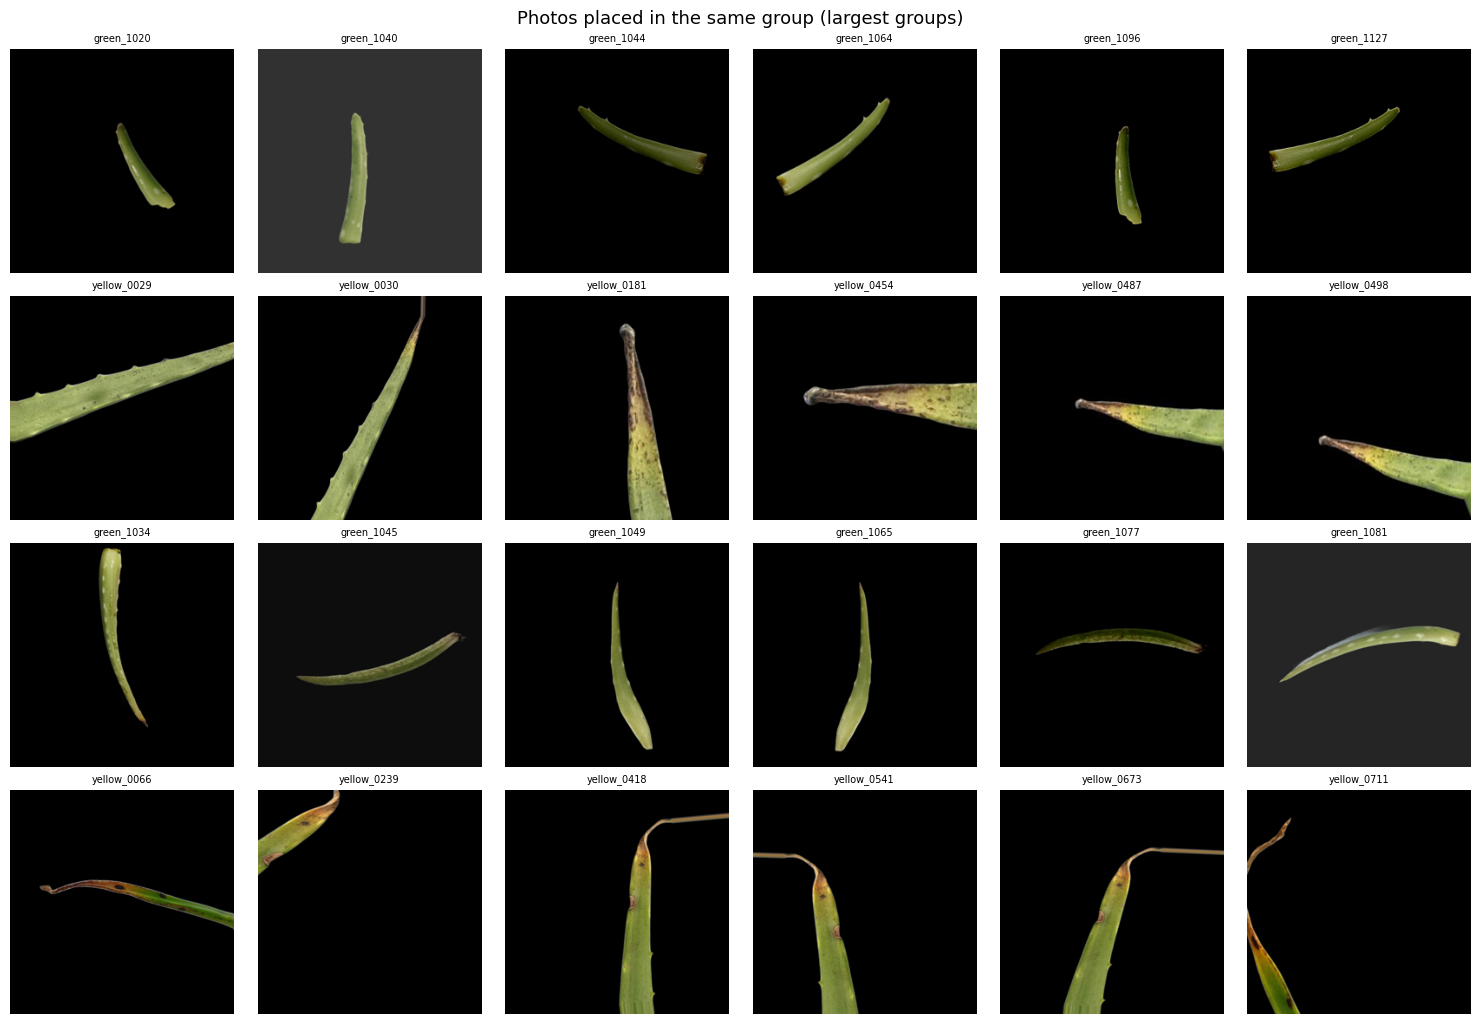

With a plain RANDOM 70/15/15 split, 94% of the held-out photos would have another version of the same original in the training set.
With the group split below this is 0%, so the validation and test scores mean something.


In [40]:
shown, fig_rows = 0, []
counts_g = np.bincount(grp[train_mask], minlength=grp.max() + 1)
for gid in np.argsort(-counts_g):
    if counts_g[gid] < 2:
        break
    if counts_g[gid] <= 60:
        fig_rows.append(np.where(grp == gid)[0][:6]); shown += 1
    if shown == 4:
        break
if fig_rows:
    fig, axes = plt.subplots(len(fig_rows), 6, figsize=(15, 2.6 * len(fig_rows)), squeeze=False)
    for ax in axes.ravel(): ax.axis("off")
    for r, members in enumerate(fig_rows):
        for k, i in enumerate(members):
            axes[r][k].imshow(arr[i])
            axes[r][k].set_title(Path(paths_all[i]).stem[-26:], fontsize=7)
    plt.suptitle("Photos placed in the same group (largest groups)", fontsize=13); plt.tight_layout(); plt.show()

# how much would a plain random split have leaked?
rng = np.random.default_rng(SEED)
tr_ids = np.where(train_mask)[0]
in_tr = np.zeros(len(tr_ids), dtype=bool)
in_tr[rng.permutation(len(tr_ids))[: int(0.7 * len(tr_ids))]] = True
members_in_train = np.bincount(grp[tr_ids], weights=in_tr.astype(float), minlength=grp.max() + 1)
leak = (members_in_train[grp[tr_ids]] - in_tr) > 0          # another photo of the same original is in the training part
print(f"With a plain RANDOM 70/15/15 split, {leak[~in_tr].mean() * 100:.0f}% of the held-out photos would have another version of the same original in the training set.")
print("With the group split below this is 0%, so the validation and test scores mean something.")

if un_paths:
    cross = (S > GROUP_SIM) & ((train_mask[I] & unseen_mask[J]) | (unseen_mask[I] & train_mask[J]))
    leaked_unseen = np.unique(np.r_[I[cross][unseen_mask[I[cross]]], J[cross][unseen_mask[J[cross]]]])
    print(f"\nUnseen photos that have a near-copy in the training data (network check): {len(leaked_unseen)} of {len(un_paths)}")

In [41]:
from sklearn.model_selection import StratifiedGroupKFold

tr_ids = np.where(train_mask)[0]
folds = list(StratifiedGroupKFold(n_splits=6, shuffle=True, random_state=SEED).split(tr_ids, y_all[tr_ids], grp[tr_ids]))
test_idx = tr_ids[folds[0][1]]
val_idx = tr_ids[folds[1][1]]
train_idx = np.setdiff1d(tr_ids, np.r_[test_idx, val_idx])

# no group may appear in two parts
g_sets = [set(grp[i]) for i in (train_idx, val_idx, test_idx)]
assert not (g_sets[0] & g_sets[1]) and not (g_sets[0] & g_sets[2]) and not (g_sets[1] & g_sets[2]), "a group crosses the split!"

# optionally train on part of the unseen photos (whole groups), keep the rest as the final test
adapt_idx = np.array([], dtype=int)
if ADD_UNSEEN_FRACTION > 0 and un_paths:
    un_ids = np.where(unseen_mask)[0]
    n_sp = max(2, round(1 / ADD_UNSEEN_FRACTION))
    uf = list(StratifiedGroupKFold(n_splits=n_sp, shuffle=True, random_state=SEED).split(un_ids, y_all[un_ids], grp[un_ids]))
    adapt_idx = un_ids[uf[0][1]]
    train_idx = np.r_[train_idx, adapt_idx]
    print(f"{len(adapt_idx)} of the {len(un_ids)} unseen photos are used for TRAINING; the other {len(un_ids) - len(adapt_idx)} stay unseen.")

for c in range(K):
    tot = int((y_all[tr_ids] == c).sum()); nv = int((y_all[val_idx] == c).sum()); nt = int((y_all[test_idx] == c).sum())
    if nv < 0.05 * tot or nt < 0.05 * tot:
        print(f"WARNING: class '{CLASSES[c]}' has only {nv} validation and {nt} test photos (of {tot}). Its groups are probably too large: raise GROUP_SIM and run from section 5 again.")
print(f"train {len(train_idx)} | validation {len(val_idx)} | test {len(test_idx)}")
print(f"{'class':25s} {'train photos':>13s} {'train originals':>16s} {'val':>6s} {'test':>6s}")
for c in range(K):
    print(f"{CLASSES[c]:25s} {int((y_all[train_idx] == c).sum()):13d} {len(set(grp[train_idx][y_all[train_idx] == c])):16d} "
          f"{int((y_all[val_idx] == c).sum()):6d} {int((y_all[test_idx] == c).sum()):6d}")

train 4030 | validation 972 | test 1105
class                      train photos  train originals    val   test
brown                               225               39     75     35
green                              1213              130    220    490
yellow                             2592              402    677    580


steps per epoch: 100


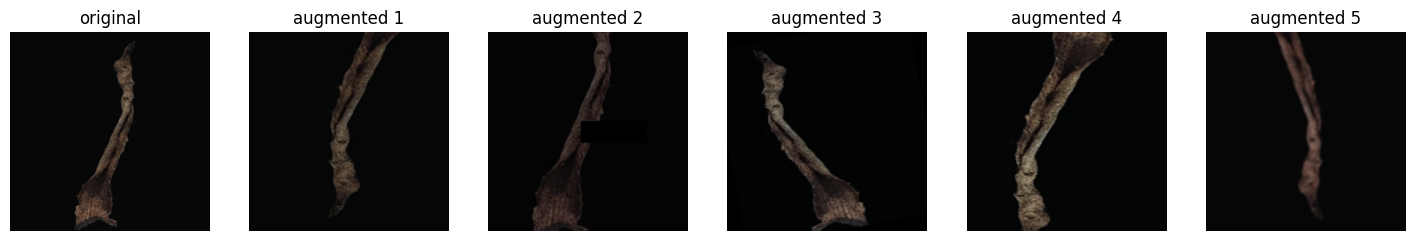

In [42]:
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

class RGBGain:
    """small random per-channel gain = white-balance / colour-cast shift"""
    def __init__(self, amount): self.amount = amount
    def __call__(self, x):
        g = 1 + (torch.rand(3, 1, 1) * 2 - 1) * self.amount
        return (x * g).clamp(0, 1)

BICUBIC = T.InterpolationMode.BICUBIC
train_tf = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.4, 1.0), ratio=(0.75, 1.33), interpolation=BICUBIC),
    T.RandomHorizontalFlip(), T.RandomVerticalFlip(),
    T.RandomApply([T.RandomRotation(20, interpolation=T.InterpolationMode.BILINEAR)], p=0.5),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.0),
    T.RandomApply([T.GaussianBlur(5, sigma=(0.1, 1.5))], p=0.3),
    T.ToTensor(), RGBGain(0.08), T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.12), value=0),
])
eval_tf = T.Compose([T.Resize((IMG_SIZE, IMG_SIZE), interpolation=BICUBIC), T.ToTensor(), T.Normalize(MEAN, STD)])

class LeafDS(Dataset):
    def __init__(self, idx, tf):
        self.idx, self.tf = np.asarray(idx), tf
    def __len__(self): return len(self.idx)
    def __getitem__(self, k):
        i = self.idx[k]
        return self.tf(Image.fromarray(arr[i])), int(y_all[i])

# sampling weights: one draw per original, equal total weight per class
gid = grp[train_idx]; ytr = y_all[train_idx]
_, inv, cnt = np.unique(gid, return_inverse=True, return_counts=True)
w = 1.0 / cnt[inv]
for c in range(K):
    m = ytr == c
    w[m] = w[m] / w[m].sum()
w = w / w.sum()
sampler = WeightedRandomSampler(torch.as_tensor(w, dtype=torch.double), num_samples=SAMPLES_PER_EPOCH, replacement=True)

train_loader = DataLoader(LeafDS(train_idx, train_tf), batch_size=BATCH, sampler=sampler, num_workers=NUM_WORKERS,
                          pin_memory=DEVICE.type == "cuda", drop_last=True, persistent_workers=NUM_WORKERS > 0)
def eval_loader(idx):
    return DataLoader(LeafDS(idx, eval_tf), batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda")
val_loader = eval_loader(val_idx)
test_loader = eval_loader(test_idx)
steps_per_epoch = len(train_loader)
print("steps per epoch:", steps_per_epoch)

# quick look at what augmentation does to one photo
img0 = Image.fromarray(arr[train_idx[0]])
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
axes[0].imshow(img0.resize((IMG_SIZE, IMG_SIZE))); axes[0].set_title("original")
for k in range(1, 6):
    x = train_tf(img0) * torch.tensor(STD).view(3, 1, 1) + torch.tensor(MEAN).view(3, 1, 1)
    axes[k].imshow(x.clamp(0, 1).permute(1, 2, 0).numpy()); axes[k].set_title(f"augmented {k}")
for a in axes: a.axis("off")
plt.show()

In [43]:
from timm.data import Mixup
from timm.loss import SoftTargetCrossEntropy
from timm.utils import ModelEmaV2

try:
    model = timm.create_model(MODEL_NAME, pretrained=PRETRAINED, num_classes=K, drop_rate=0.2, drop_path_rate=0.1)
except TypeError:            # older timm versions have no drop_path_rate for TResNet
    model = timm.create_model(MODEL_NAME, pretrained=PRETRAINED, num_classes=K, drop_rate=0.2)
model = model.to(DEVICE).to(memory_format=torch.channels_last)
print(MODEL_NAME, "| parameters:", f"{sum(p.numel() for p in model.parameters()):,}")

head_ids = {id(p) for p in model.get_classifier().parameters()}
body = [p for p in model.parameters() if id(p) not in head_ids]
head = [p for p in model.parameters() if id(p) in head_ids]
optimizer = torch.optim.AdamW([{"params": body, "lr": LR}, {"params": head, "lr": LR * HEAD_LR_MULT}], weight_decay=WEIGHT_DECAY)

total_steps, warm = EPOCHS * steps_per_epoch, steps_per_epoch
def lr_lambda(s):
    if s < warm:
        return (s + 1) / warm
    return max(0.02, 0.5 * (1 + math.cos(math.pi * (s - warm) / max(1, total_steps - warm))))
sched = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

mixup_fn = Mixup(mixup_alpha=0.2, cutmix_alpha=1.0, prob=0.5, switch_prob=0.5, label_smoothing=LABEL_SMOOTH, num_classes=K) if USE_MIXUP else None
criterion = SoftTargetCrossEntropy() if USE_MIXUP else nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)
ema = ModelEmaV2(model, decay=EMA_DECAY)
try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
except Exception:
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

tresnet_m.miil_in21k_ft_in1k | parameters: 29,346,179


epoch  1/30 | train loss 0.664 | val loss 1.003 | val acc  59.2% | val macro-F1 0.559 | 20s  *best*
epoch  2/30 | train loss 0.361 | val loss 0.904 | val acc  67.1% | val macro-F1 0.671 | 21s  *best*
epoch  3/30 | train loss 0.344 | val loss 0.802 | val acc  69.0% | val macro-F1 0.688 | 21s  *best*
epoch  4/30 | train loss 0.331 | val loss 0.690 | val acc  75.1% | val macro-F1 0.732 | 20s  *best*
epoch  5/30 | train loss 0.320 | val loss 0.572 | val acc  81.1% | val macro-F1 0.786 | 20s  *best*
epoch  6/30 | train loss 0.318 | val loss 0.459 | val acc  86.8% | val macro-F1 0.838 | 20s  *best*
epoch  7/30 | train loss 0.314 | val loss 0.365 | val acc  89.9% | val macro-F1 0.868 | 20s  *best*
epoch  8/30 | train loss 0.316 | val loss 0.292 | val acc  93.2% | val macro-F1 0.902 | 20s  *best*
epoch  9/30 | train loss 0.310 | val loss 0.241 | val acc  94.8% | val macro-F1 0.918 | 20s  *best*
epoch 10/30 | train loss 0.310 | val loss 0.208 | val acc  95.7% | val macro-F1 0.927 | 21s  *best*


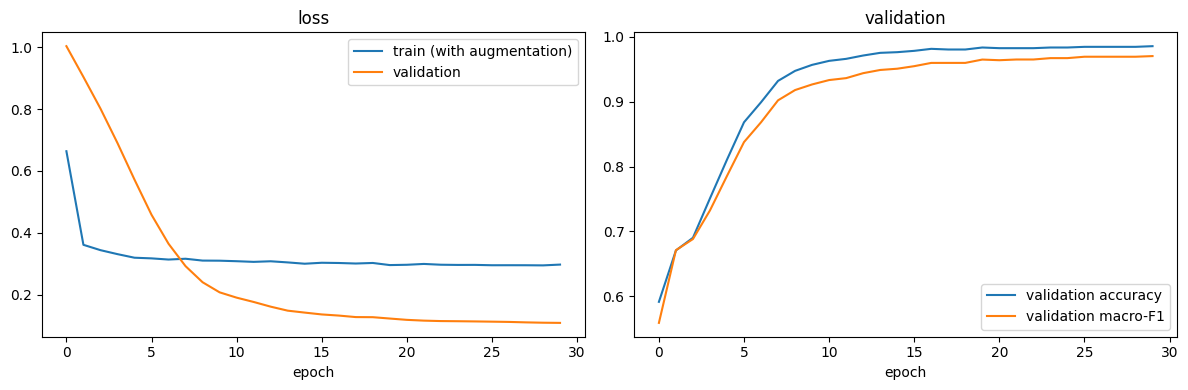

In [44]:
@torch.no_grad()
def predict(m, loader):
    m.eval(); out = []
    for x, _ in loader:
        x = x.to(DEVICE, non_blocking=True).contiguous(memory_format=torch.channels_last)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            out.append(m(x).float().softmax(1).cpu())
    return torch.cat(out).numpy()

y_val = y_all[val_idx]
hist = {"train_loss": [], "val_loss": [], "val_acc": [], "val_f1": []}
best = {"f1": -1, "loss": 1e9, "state": None, "epoch": 0}
bad = 0
for epoch in range(1, EPOCHS + 1):
    model.train(); t0 = time.time(); run = 0.0
    for x, y in train_loader:
        x = x.to(DEVICE, non_blocking=True).contiguous(memory_format=torch.channels_last); y = y.to(DEVICE, non_blocking=True)
        if mixup_fn is not None:
            x, y = mixup_fn(x, y)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=USE_AMP):
            loss = criterion(model(x), y)
        optimizer.zero_grad(set_to_none=True)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer); scaler.update(); sched.step(); ema.update(model)
        run += loss.item()
    pv = predict(ema.module, val_loader)
    vloss = float(-np.log(pv[np.arange(len(y_val)), y_val] + 1e-8).mean())
    vacc = accuracy_score(y_val, pv.argmax(1)); vf1 = f1_score(y_val, pv.argmax(1), average="macro", zero_division=0)
    hist["train_loss"].append(run / steps_per_epoch); hist["val_loss"].append(vloss); hist["val_acc"].append(vacc); hist["val_f1"].append(vf1)
    improved = vf1 > best["f1"] + 1e-4 or (abs(vf1 - best["f1"]) <= 1e-4 and vloss < best["loss"])
    if improved:
        best.update(f1=vf1, loss=vloss, epoch=epoch, state=copy.deepcopy(ema.module.state_dict())); bad = 0
    else:
        bad += 1
    print(f"epoch {epoch:2d}/{EPOCHS} | train loss {run / steps_per_epoch:.3f} | val loss {vloss:.3f} | val acc {vacc * 100:5.1f}% | val macro-F1 {vf1:.3f}"
          f" | {time.time() - t0:.0f}s" + ("  *best*" if improved else ""))
    if bad >= PATIENCE:
        print(f"early stop: no improvement for {PATIENCE} epochs"); break

print(f"\nbest epoch {best['epoch']}: validation macro-F1 {best['f1']:.3f}, loss {best['loss']:.3f}")
ema.module.load_state_dict(best["state"])
final_model = ema.module

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(hist["train_loss"], label="train (with augmentation)"); ax[0].plot(hist["val_loss"], label="validation"); ax[0].set_title("loss"); ax[0].legend(); ax[0].set_xlabel("epoch")
ax[1].plot(hist["val_acc"], label="validation accuracy"); ax[1].plot(hist["val_f1"], label="validation macro-F1"); ax[1].set_title("validation"); ax[1].legend(); ax[1].set_xlabel("epoch")
plt.tight_layout(); plt.show()


===== HELD-OUT TEST split (group split): accuracy 99.64% | macro F1 0.997 =====

              precision    recall  f1-score   support

       brown      1.000     1.000     1.000        35
       green      0.994     0.998     0.996       490
      yellow      0.998     0.995     0.997       580

    accuracy                          0.996      1105
   macro avg      0.997     0.998     0.997      1105
weighted avg      0.996     0.996     0.996      1105

How often each class really occurs vs how often the model predicts it
(one class predicted far more than it occurs = the model is falling back on it):
  brown                     true   35 | predicted   35
  green                     true  490 | predicted  492
  yellow                    true  580 | predicted  578

Most common mix-ups (count: true -> predicted):
     3: yellow -> green
     1: green -> yellow

confusion matrix (rows = true, columns = predicted): ['brown', 'green', 'yellow']
[[ 35   0   0]
 [  0 489   1]
 [  0   3 5

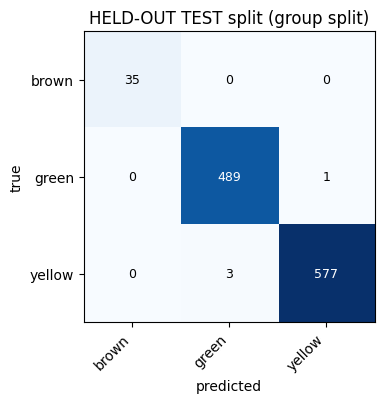


Good vs not good accuracy: 99.64%
'not good' photos called GOOD: 3 of 615
'good' photos called NOT GOOD: 1 of 490
(Always answering 'not good' would score 55.7%)


In [45]:
def plot_cm(cm, title):
    size = max(4.6, 0.65 * K + 2.5)
    fig, ax = plt.subplots(figsize=(size, size * 0.9))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(IDX); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(IDX); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    for i in IDX:
        for j in IDX:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=9,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    plt.tight_layout(); plt.show()

def binary_check(y, pred):
    if POS_CLASS not in class_to_idx:
        return
    a, b = POS_NAMES
    g = class_to_idx[POS_CLASS]
    t, p = (y == g), (pred == g)
    print(f"\n{a.capitalize()} vs {b} accuracy: {(t == p).mean() * 100:.2f}%")
    print(f"'{b}' photos called {a.upper()}: {int(((~t) & p).sum())} of {int((~t).sum())}")
    print(f"'{a}' photos called {b.upper()}: {int((t & ~p).sum())} of {int(t.sum())}")
    print(f"(Always answering '{b}' would score {(~t).mean() * 100:.1f}%)")

def report(y, pred, name):
    """Accuracy, per-class report, how often each class is predicted, main mix-ups, confusion matrix."""
    acc = accuracy_score(y, pred)
    f1 = f1_score(y, pred, average="macro", labels=sorted(set(y)), zero_division=0)
    print(f"\n===== {name}: accuracy {acc * 100:.2f}% | macro F1 {f1:.3f} =====\n")
    print(classification_report(y, pred, labels=IDX, target_names=CLASSES, digits=3, zero_division=0))
    print("How often each class really occurs vs how often the model predicts it")
    print("(one class predicted far more than it occurs = the model is falling back on it):")
    for i, c in enumerate(CLASSES):
        print(f"  {c:25s} true {int((y == i).sum()):4d} | predicted {int((pred == i).sum()):4d}")
    cm = confusion_matrix(y, pred, labels=IDX)
    pairs = sorted(((cm[i, j], CLASSES[i], CLASSES[j]) for i in IDX for j in IDX if i != j and cm[i, j] > 0), reverse=True)[:8]
    if pairs:
        print("\nMost common mix-ups (count: true -> predicted):")
        for n, a, b in pairs:
            print(f"  {n:4d}: {a} -> {b}")
    print("\nconfusion matrix (rows = true, columns = predicted):", CLASSES)
    print(cm)
    plot_cm(cm, name)
    binary_check(y, pred)
    return acc, f1

y_t = y_all[test_idx]
pred_t = predict(final_model, test_loader).argmax(1)
test_acc, test_f1 = report(y_t, pred_t, "HELD-OUT TEST split (group split)")

In [46]:
import zipfile
from IPython.display import FileLink, display

ckpt = {"state_dict": {k: v.cpu() for k, v in final_model.state_dict().items()}, "classes": CLASSES, "model_name": MODEL_NAME,
        "img_size": IMG_SIZE, "res": RES, "mean": list(MEAN), "std": list(STD)}
model_file = f"{OUT_DIR}/{PREFIX}_{BASE}.pt"
labels_file = f"{OUT_DIR}/{PREFIX}_{BASE}_labels.txt"
used_file = f"{OUT_DIR}/{PREFIX}_{BASE}_unseen_used_for_training.txt"
torch.save(ckpt, model_file)
Path(labels_file).write_text("\n".join(CLASSES))
Path(used_file).write_text("\n".join(f"{labels_all[i]}/{Path(paths_all[i]).name}" for i in adapt_idx))    # empty if no unseen photo was used
print("saved:", model_file, "\nsaved:", labels_file, "\nsaved:", used_file, f"({len(adapt_idx)} unseen photos used for training)")

os.chdir(OUT_DIR)
zip_name = f"aloe_{PREFIX}_tresnet_model.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for f in (model_file, labels_file, used_file):
        z.write(f, arcname=Path(f).name)
print("zip:", f"{OUT_DIR}/{zip_name}", f"({Path(zip_name).stat().st_size / 1e6:.0f} MB)")
display(FileLink(zip_name))

print("\n================ SUMMARY ================")
print(f"model         : {MODEL_NAME}   ({K} classes)")
print(f"held-out test : accuracy {test_acc * 100:.2f}% | macro F1 {test_f1:.3f}   (group split, so no copies in training)")
print("\nNext: Save Version -> Save & Run All (Commit), then open the second notebook (unseen evaluation).")

saved: /kaggle/working/colour_tresnet_m.pt 
saved: /kaggle/working/colour_tresnet_m_labels.txt 
saved: /kaggle/working/colour_tresnet_m_unseen_used_for_training.txt (0 unseen photos used for training)
zip: /kaggle/working/aloe_colour_tresnet_model.zip (109 MB)


/kaggle/working/aloe_colour_tresnet_model.zip


================ SUMMARY ================
model         : tresnet_m.miil_in21k_ft_in1k   (3 classes)
held-out test : accuracy 99.64% | macro F1 0.997   (group split, so no copies in training)

Next: Save Version -> Save & Run All (Commit), then open the second notebook (unseen evaluation).


In [47]:
import os, zipfile
from pathlib import Path
from IPython.display import FileLink, display

TASK = "colour"        # "colour" or "disease"
KIND = "tresnet"        # "tresnet" (the .pt model) or "efficientnet" (the .keras model)

ext = ".pt" if KIND == "tresnet" else ".keras"
found = [p for root in ["/kaggle/working", "/kaggle/input"] for p in Path(root).rglob(f"{TASK}_{KIND}*{ext}")]
assert found, f"No {TASK}_{KIND}*{ext} found. Run the training notebook first, or add it as an input."
model = max(found, key=lambda p: p.stat().st_mtime)                     # the newest one
files = [model] + [model.with_name(model.stem + s) for s in ("_labels.txt", "_unseen_used_for_training.txt")]

os.chdir("/kaggle/working")
zip_name = f"aloe_{TASK}_{KIND}_model.zip"
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as z:
    for f in files:
        if f.exists():
            z.write(f, arcname=f.name)
print("Zipped:", zipfile.ZipFile(zip_name).namelist(), f"({Path(zip_name).stat().st_size / 1e6:.1f} MB)")
display(FileLink(zip_name))

Zipped: ['colour_tresnet_m.pt', 'colour_tresnet_m_labels.txt', 'colour_tresnet_m_unseen_used_for_training.txt'] (108.6 MB)


/kaggle/working/aloe_colour_tresnet_model.zip